In [25]:
import os
import glob
import random
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

# 路径配置
BASE_DIR = r'D:\Project_Github\Indo-Pacific-humpback-dolphin'
DATA_DIR = os.path.join(BASE_DIR, '00_Data')
POS_CLEAN_DIR = os.path.join(BASE_DIR, '03_Distinguish', 'Output_Classification', 'Clean')
POS_MODERATE_DIR = os.path.join(BASE_DIR, '03_Distinguish', 'Output_Classification', 'Moderate')
POS_SEVERE_DIR = os.path.join(BASE_DIR, '03_Distinguish', 'Output_Classification', 'Severe')
NEG_DIR = os.path.join(DATA_DIR, '02_ClickDetection', 'FalseClick')

# 参数设置
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
SR = None  # 保持原始采样率
FIXED_LENGTH = 1024 # 假设波形长度固定，如果不固定，后续代码会自动截断/填充

In [26]:
# 1. 获取正样本文件 (Clean + Moderate)
pos_files = glob.glob(os.path.join(POS_CLEAN_DIR, "*.wav")) + \
            glob.glob(os.path.join(POS_MODERATE_DIR, "*.wav"))
print(f"找到正样本数量: {len(pos_files)}")

# 2. 递归获取所有负样本文件
all_neg_files = []
for root, dirs, files in os.walk(NEG_DIR):
    for file in files:
        if file.endswith(".wav"):
            all_neg_files.append(os.path.join(root, file))

# 随机抽取 884 (配比正样本) + 100 (难度测试集用)
total_neg_needed = 884 + 300
sampled_neg_files = random.sample(all_neg_files, total_neg_needed)

train_test_neg_files = sampled_neg_files[:884]
hard_test_neg_files = sampled_neg_files[884:]

# 3. 获取难度测试集正样本 (Severe)
hard_pos_files = glob.glob(os.path.join(POS_SEVERE_DIR, "*.wav"))
hard_pos_files = random.sample(hard_pos_files, 300) # 按要求取100个

print(f"用于训练/测试的负样本: {len(train_test_neg_files)}")
print(f"用于难度测试的正样本: {len(hard_pos_files)}")
print(f"用于难度测试的负样本: {len(hard_test_neg_files)}")

找到正样本数量: 884
用于训练/测试的负样本: 884
用于难度测试的正样本: 300
用于难度测试的负样本: 300


In [27]:
def load_audio_and_augment(file_path, target_length=116, augment=True):
    # 加载音频
    y, sr = librosa.load(file_path, sr=SR)
    
    # 填充或截断到固定长度
    if len(y) > target_length:
        y = y[:target_length]
    else:
        y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')
    
    # 随机平移增强 (Roll)
    if augment:
        shift = np.random.randint(-target_length // 4, target_length // 4)
        y = np.roll(y, shift)
        
    return y

def prepare_dataset(files, label, augment=True):
    data = []
    labels = []
    for f in files:
        waveform = load_audio_and_augment(f, augment=augment)
        data.append(waveform)
        labels.append(label)
    return np.array(data), np.array(labels)

# 加载主数据集
X_pos, y_pos = prepare_dataset(pos_files, 1, augment=True)
X_neg, y_neg = prepare_dataset(train_test_neg_files, 0, augment=True)

X = np.vstack([X_pos, X_neg])
y = np.concatenate([y_pos, y_neg])

# 加载难度测试集
X_hard_pos, y_hard_pos = prepare_dataset(hard_pos_files, 1, augment=False)
X_hard_neg, y_hard_neg = prepare_dataset(hard_test_neg_files, 0, augment=False)

X_hard_test = np.vstack([X_hard_pos, X_hard_neg])
y_hard_test = np.concatenate([y_hard_pos, y_hard_neg])

print(f"主数据集维度: {X.shape}")

主数据集维度: (1768, 116)


正在计算 t-SNE...


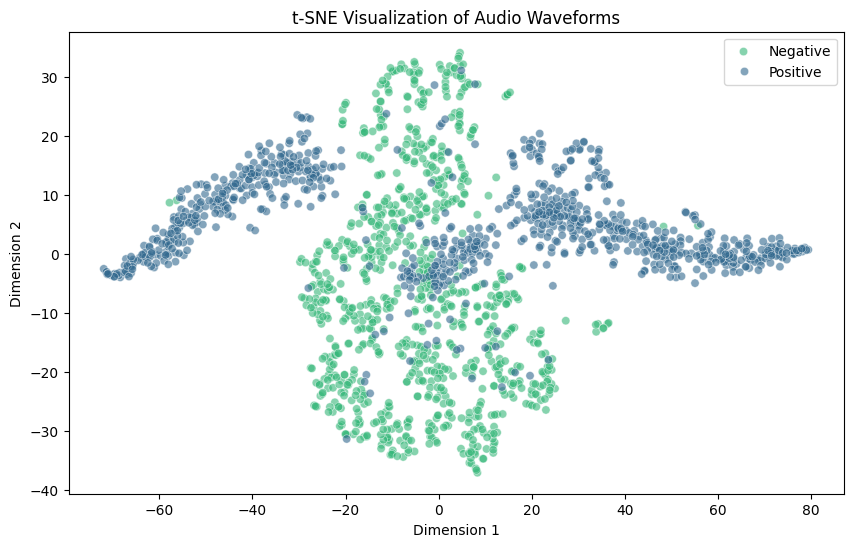

In [28]:
print("正在计算 t-SNE...")
tsne = TSNE(n_components=2, random_state=SEED)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y, palette='viridis', alpha=0.6)
plt.title('t-SNE Visualization of Audio Waveforms')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(['Negative', 'Positive'])
plt.show()

In [29]:
# 5. 划分 8:2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# 6. XGBoost 5折交叉验证
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=kf, scoring='accuracy')

print(f"5折交叉验证 Accuracy: {cv_scores}")
print(f"平均 Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

5折交叉验证 Accuracy: [0.95053004 0.95053004 0.93286219 0.92226148 0.93971631]
平均 Accuracy: 0.9392 (+/- 0.0216)


d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [30]:
# 训练模型
xgb_model.fit(X_train, y_train)

# 预测
y_pred = xgb_model.predict(X_test)

print("--- 标准测试集分类报告 (8:2 Split) ---")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

d:\Python_env\Detector\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- 标准测试集分类报告 (8:2 Split) ---
              precision    recall  f1-score   support

    Negative       0.95      0.94      0.95       177
    Positive       0.94      0.95      0.95       177

    accuracy                           0.95       354
   macro avg       0.95      0.95      0.95       354
weighted avg       0.95      0.95      0.95       354



--- 难度测试集分类报告 (Severe Positive + Random Negative) ---
              precision    recall  f1-score   support

    Negative       1.00      0.94      0.97       300
    Positive       0.94      1.00      0.97       300

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



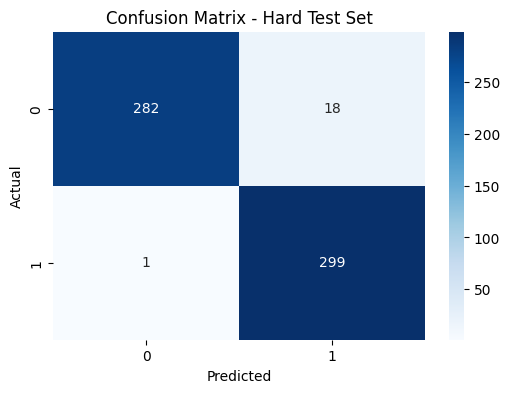

In [31]:
# 使用已经训练好的模型对难度测试集进行预测
y_hard_pred = xgb_model.predict(X_hard_test)

print("--- 难度测试集分类报告 (Severe Positive + Random Negative) ---")
print(classification_report(y_hard_test, y_hard_pred, target_names=['Negative', 'Positive']))

# 可选：绘制混淆矩阵
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_hard_test, y_hard_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Hard Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [32]:
import librosa

# 选择一个文件路径（换成你自己的路径）
file_path = r'D:\Project_Github\Indo-Pacific-humpback-dolphin\03_Distinguish\Output_Classification\Clean\PulseTrain_011_Pulse_9.wav'

# 加载音频
# sr=None 表示保持原始采样率，不进行重采样
y, sr = librosa.load(file_path, sr=None)

print(f"音频信息:")
print(f"采样率 (Sampling Rate): {sr} Hz")
print(f"总采样点数 (Total Samples): {len(y)}")
print(f"音频时长 (Duration): {len(y)/sr:.4f} 秒")

音频信息:
采样率 (Sampling Rate): 576000 Hz
总采样点数 (Total Samples): 116
音频时长 (Duration): 0.0002 秒
